In [6]:
from google.colab import files
uploaded = files.upload()

Saving hotel_bookings.csv to hotel_bookings (1).csv


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print('✅ Libraries imported successfully!')

✅ Libraries imported successfully!


In [8]:
df = pd.read_csv('hotel_bookings.csv')

print(f'Dataset Shape: {df.shape}')
print(f'\nColumn Names:\n{list(df.columns)}')

Dataset Shape: (119390, 32)

Column Names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']


In [9]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [11]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


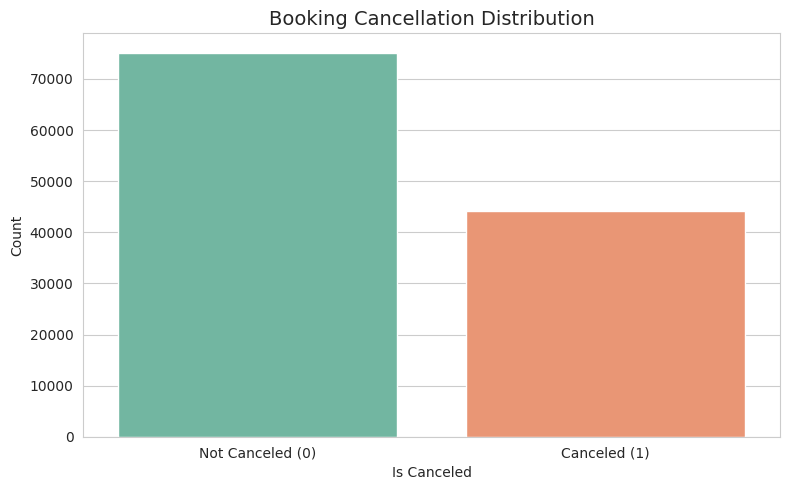

Cancellation Rate: 37.0%


In [12]:
cancellation_counts = df['is_canceled'].value_counts()
labels = ['Not Canceled (0)', 'Canceled (1)']

plt.figure(figsize=(8, 5))
sns.countplot(x='is_canceled', data=df, palette='Set2')
plt.title('Booking Cancellation Distribution', fontsize=14)
plt.xlabel('Is Canceled')
plt.ylabel('Count')
plt.xticks([0, 1], labels)
plt.tight_layout()
plt.show()

print(f'Cancellation Rate: {df["is_canceled"].mean()*100:.1f}%')

Missing Values:
company     112593
agent        16340
country        488
children         4
dtype: int64


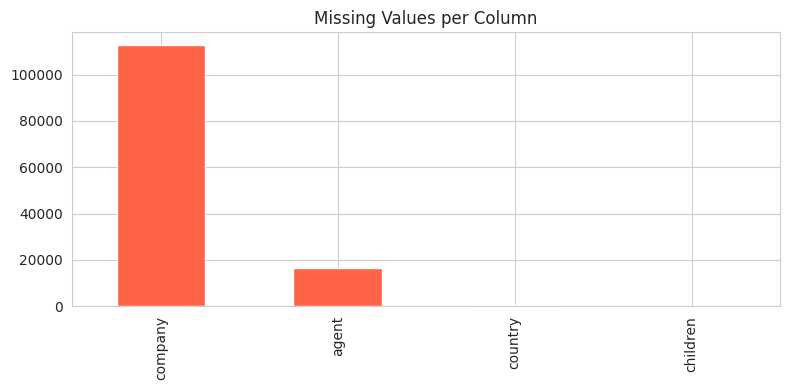

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print('Missing Values:')
print(missing)

plt.figure(figsize=(8, 4))
missing.plot(kind='bar', color='tomato')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()

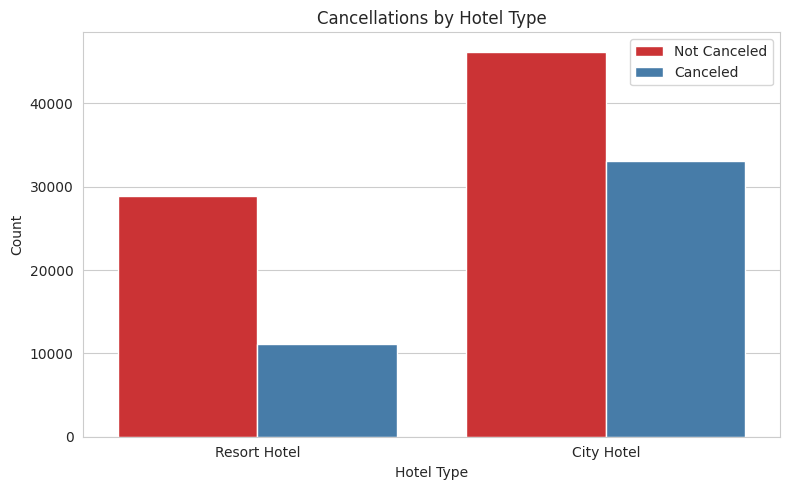

In [14]:
plt.figure(figsize=(8, 5))
sns.countplot(x='hotel', hue='is_canceled', data=df, palette='Set1')
plt.title('Cancellations by Hotel Type')
plt.xlabel('Hotel Type')
plt.ylabel('Count')
plt.legend(['Not Canceled', 'Canceled'])
plt.tight_layout()
plt.show()

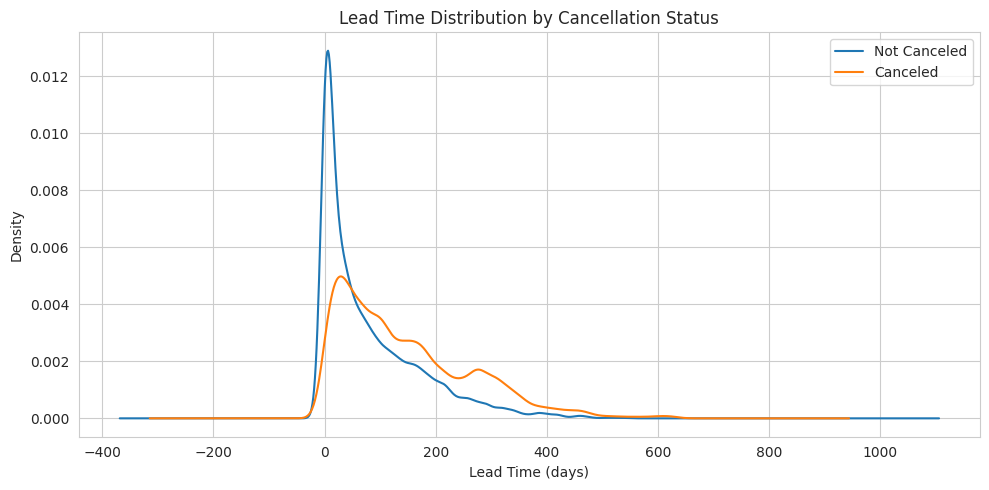

In [15]:
plt.figure(figsize=(10, 5))
df.groupby('is_canceled')['lead_time'].plot(kind='density', legend=True)
plt.title('Lead Time Distribution by Cancellation Status')
plt.xlabel('Lead Time (days)')
plt.legend(['Not Canceled', 'Canceled'])
plt.tight_layout()
plt.show()

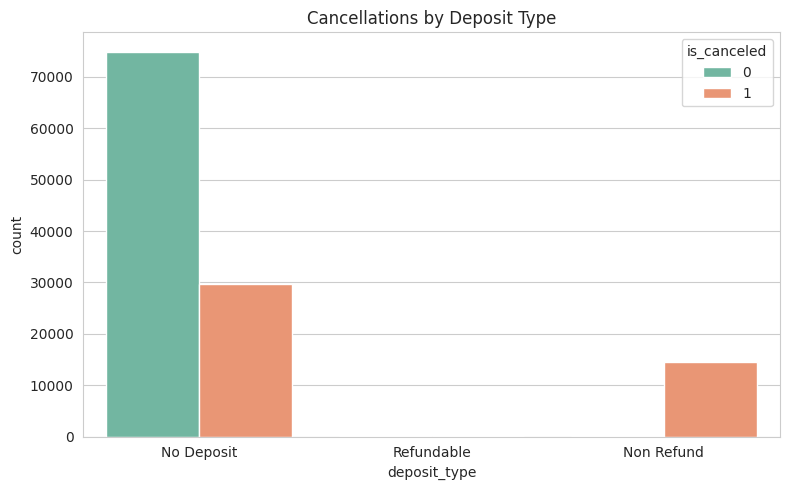

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='deposit_type', hue='is_canceled', data=df, palette='Set2')
plt.title('Cancellations by Deposit Type')
plt.tight_layout()
plt.show()

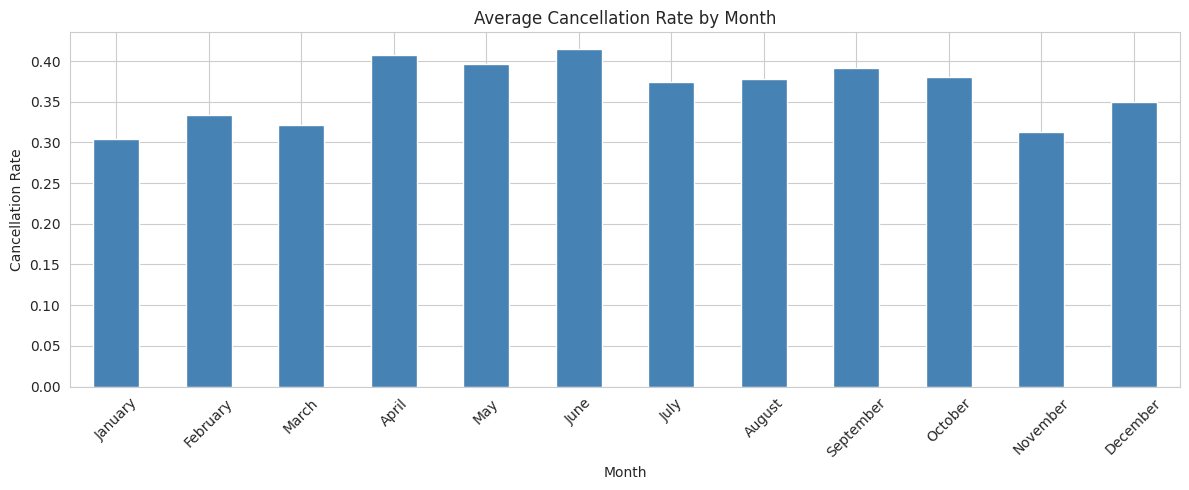

In [17]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly = df.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order)

plt.figure(figsize=(12, 5))
monthly.plot(kind='bar', color='steelblue')
plt.title('Average Cancellation Rate by Month')
plt.xlabel('Month')
plt.ylabel('Cancellation Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
df.drop(columns=['reservation_status', 'reservation_status_date'], inplace=True)

# Fill missing values
df['children'].fillna(0, inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['agent'].fillna(0, inplace=True)
df['company'].fillna(0, inplace=True)

print('✅ Missing values handled!')
print(f'Remaining nulls: {df.isnull().sum().sum()}')

✅ Missing values handled!
Remaining nulls: 0


In [19]:
df['total_guests'] = df['adults'] + df['children'] + df['babies']
df['total_nights'] = df['stays_in_week_nights'] + df['stays_in_weekend_nights']
df['has_special_requests'] = (df['total_of_special_requests'] > 0).astype(int)

# Remove rows where total_nights = 0 (invalid bookings)
df = df[df['total_nights'] > 0]

print(f'✅ Features engineered! New shape: {df.shape}')

✅ Features engineered! New shape: (118675, 33)


In [20]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns to encode: {cat_cols}')

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('✅ Encoding complete!')

Categorical columns to encode: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']
✅ Encoding complete!


In [21]:
X = df.drop('is_canceled', axis=1)
y = df['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set: {X_train.shape}')
print(f'Test set:     {X_test.shape}')
print(f'Cancellation rate in train: {y_train.mean()*100:.1f}%')
print(f'Cancellation rate in test:  {y_test.mean()*100:.1f}%')

Training set: (94940, 32)
Test set:     (23735, 32)
Cancellation rate in train: 37.2%
Cancellation rate in test:  37.2%


In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'accuracy': report['accuracy'],
        'f1': report['weighted avg']['f1-score'],
        'roc_auc': auc
    }
    print(f'{name}: Accuracy={report["accuracy"]:.4f}, F1={report["weighted avg"]["f1-score"]:.4f}, ROC-AUC={auc:.4f}')

Logistic Regression: Accuracy=0.7951, F1=0.7875, ROC-AUC=0.8671
Decision Tree: Accuracy=0.8418, F1=0.8399, ROC-AUC=0.9188
Random Forest: Accuracy=0.8933, F1=0.8923, ROC-AUC=0.9602
Gradient Boosting: Accuracy=0.8504, F1=0.8481, ROC-AUC=0.9252


                     Accuracy  F1-Score  ROC-AUC
Logistic Regression    0.7951    0.7875   0.8671
Decision Tree          0.8418    0.8399   0.9188
Random Forest          0.8933    0.8923   0.9602
Gradient Boosting      0.8504    0.8481   0.9252


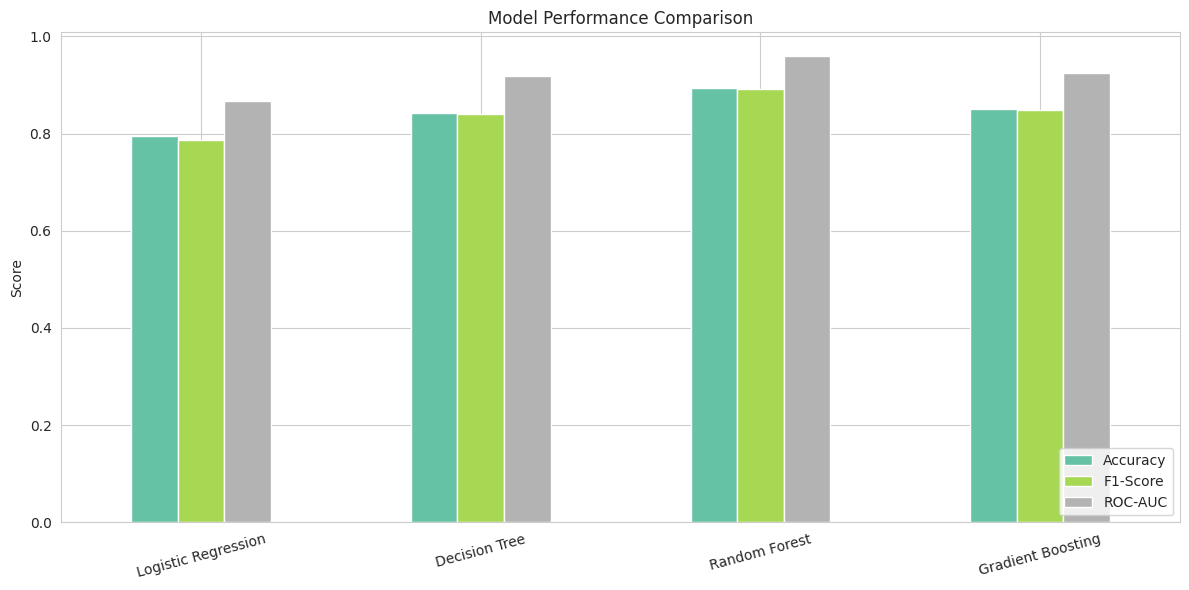

In [24]:
comparison_df = pd.DataFrame({
    name: {
        'Accuracy': res['accuracy'],
        'F1-Score': res['f1'],
        'ROC-AUC': res['roc_auc']
    }
    for name, res in results.items()
}).T

print(comparison_df.round(4))

comparison_df.plot(kind='bar', figsize=(12, 6), colormap='Set2')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

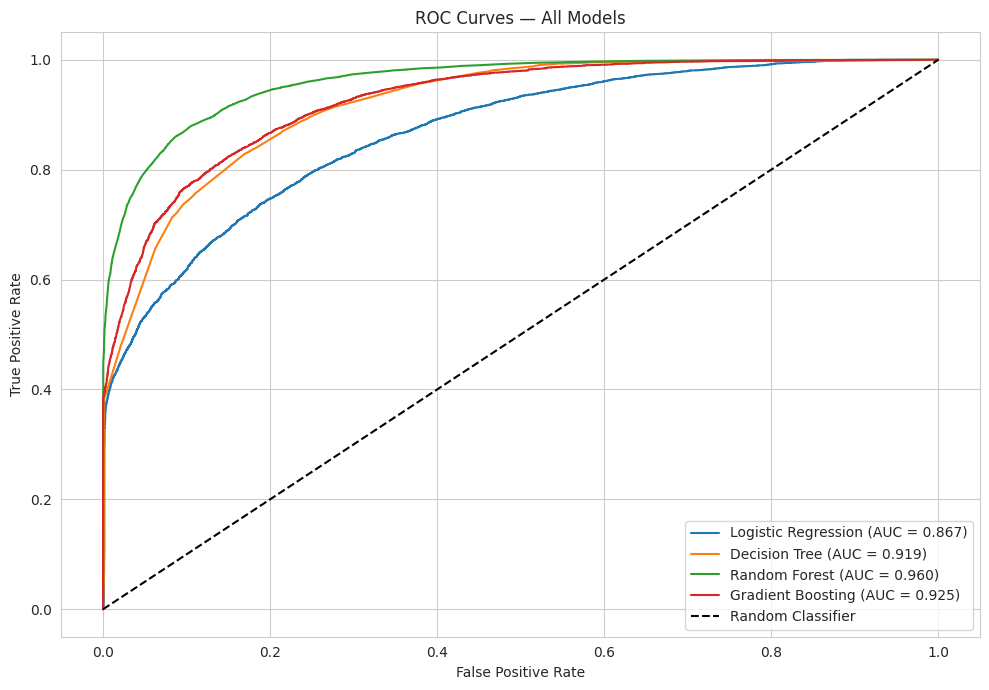

In [25]:
plt.figure(figsize=(10, 7))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {res['roc_auc']:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend()
plt.tight_layout()
plt.show()

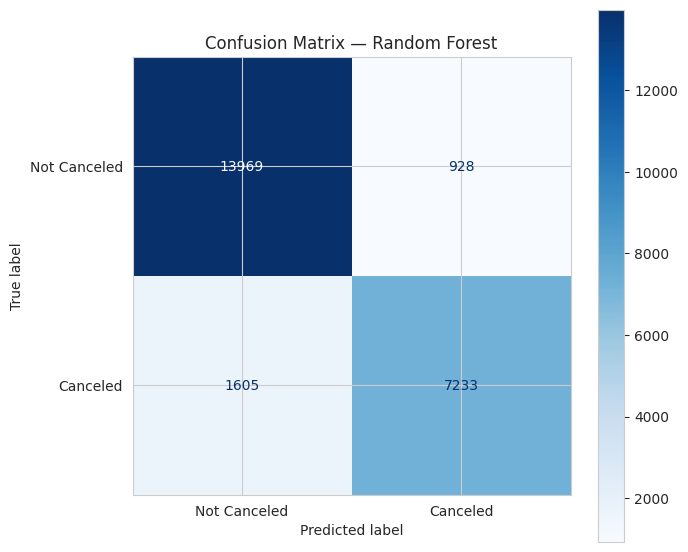

              precision    recall  f1-score   support

Not Canceled       0.90      0.94      0.92     14897
    Canceled       0.89      0.82      0.85      8838

    accuracy                           0.89     23735
   macro avg       0.89      0.88      0.88     23735
weighted avg       0.89      0.89      0.89     23735



In [26]:
best_model_name = 'Random Forest'
best_results = results[best_model_name]

cm = confusion_matrix(y_test, best_results['y_pred'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Canceled', 'Canceled'])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_results['y_pred'], target_names=['Not Canceled', 'Canceled']))

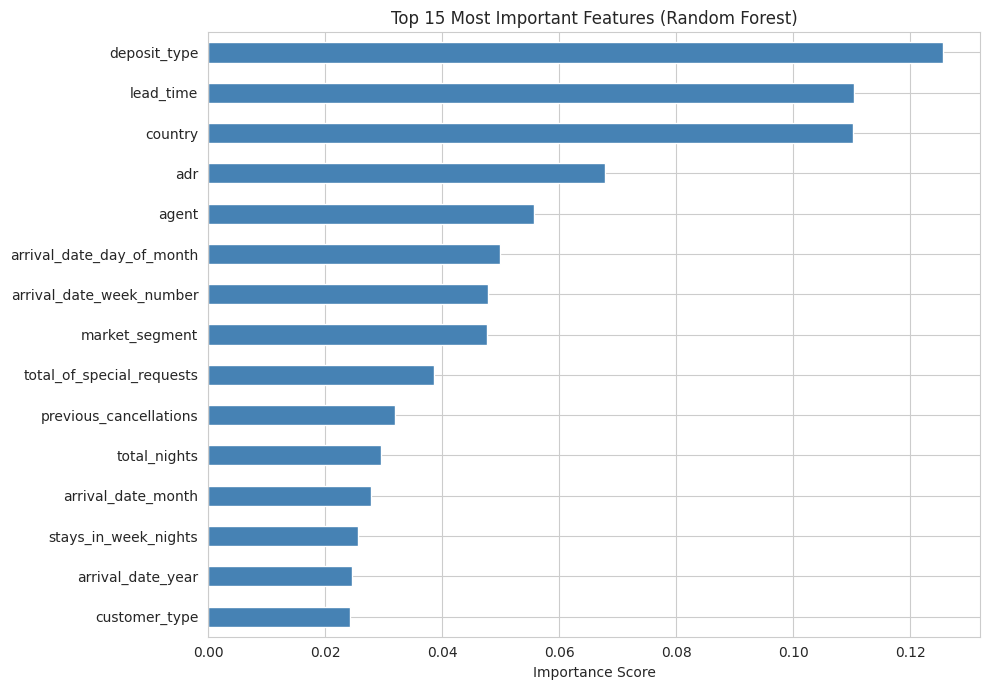

In [27]:
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_features = importances.nlargest(15).sort_values()

plt.figure(figsize=(10, 7))
top_features.plot(kind='barh', color='steelblue')
plt.title('Top 15 Most Important Features (Random Forest)')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Cross-Validation ROC-AUC Scores: [0.5711 0.5622 0.451  0.4053 0.6544]
Mean: 0.5288 ± 0.0894


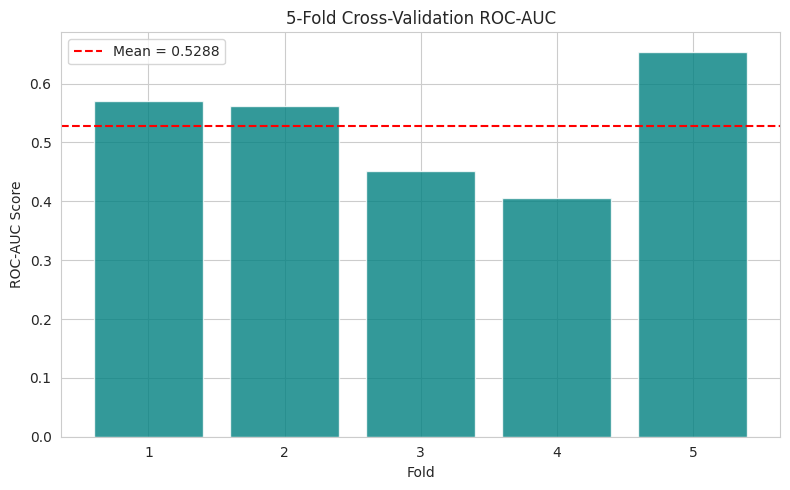

In [28]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='roc_auc')

print(f'Cross-Validation ROC-AUC Scores: {cv_scores.round(4)}')
print(f'Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

plt.figure(figsize=(8, 5))
plt.bar(range(1, 6), cv_scores, color='teal', alpha=0.8)
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.title('5-Fold Cross-Validation ROC-AUC')
plt.xlabel('Fold')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
sample = X_test.iloc[[0]].copy()

rf_model.fit(X_train, y_train)

prediction = rf_model.predict(sample)[0]
probability = rf_model.predict_proba(sample)[0][1]

print(f'Prediction: {"✅ NOT Canceled" if prediction == 0 else "❌ CANCELED"}')
print(f'Cancellation Probability: {probability*100:.1f}%')

Prediction: ✅ NOT Canceled
Cancellation Probability: 10.0%


In [30]:
print('=' * 60)
print('          PROJECT SUMMARY: HOTEL BOOKING CANCELLATIONS')
print('=' * 60)

print('\n📌 Dataset:')
print(f'   - {df.shape[0]:,} bookings | {df.shape[1]} features')

print('\n📌 Model Performance (Test Set):')
for name, res in results.items():
    print(f'   {name:<25} Accuracy: {res["accuracy"]:.3f} | ROC-AUC: {res["roc_auc"]:.3f}')

best_name = max(results, key=lambda x: results[x]['roc_auc'])
print(f'\n🏆 Best Model: {best_name}')
print(f'   ROC-AUC: {results[best_name]["roc_auc"]:.4f}')

print('\n📌 Key Predictors of Cancellation:')
print('   1. Lead Time (days before arrival)')
print('   2. Deposit Type')
print('   3. Previous Cancellations')
print('   4. Market Segment')
print('   5. Special Requests')

print('\n📌 Business Recommendations:')
print('   - Flag high-risk bookings for overbooking strategy')
print('   - Offer incentives to customers with long lead times')
print('   - Require deposits for high-risk customer segments')
print('=' * 60)

          PROJECT SUMMARY: HOTEL BOOKING CANCELLATIONS

📌 Dataset:
   - 118,675 bookings | 33 features

📌 Model Performance (Test Set):
   Logistic Regression       Accuracy: 0.795 | ROC-AUC: 0.867
   Decision Tree             Accuracy: 0.842 | ROC-AUC: 0.919
   Random Forest             Accuracy: 0.893 | ROC-AUC: 0.960
   Gradient Boosting         Accuracy: 0.850 | ROC-AUC: 0.925

🏆 Best Model: Random Forest
   ROC-AUC: 0.9602

📌 Key Predictors of Cancellation:
   1. Lead Time (days before arrival)
   2. Deposit Type
   3. Previous Cancellations
   4. Market Segment
   5. Special Requests

📌 Business Recommendations:
   - Flag high-risk bookings for overbooking strategy
   - Offer incentives to customers with long lead times
   - Require deposits for high-risk customer segments
